# Bassam Kasar India Unemployment Analysis COVID 19 Impact Project

# 1. Let's first import the required libraries

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load and Inspect the Data

In [11]:
df = pd.read_csv('Unemployment in India.csv')
print("\nShape:", df.shape)
print("\nHead:\n", df.head())
print("\nInfo:")
df.info()


Shape: (768, 7)

Head:
            Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019    Monthly                              3.65   
1  Andhra Pradesh   30-06-2019    Monthly                              3.05   
2  Andhra Pradesh   31-07-2019    Monthly                              3.75   
3  Andhra Pradesh   31-08-2019    Monthly                              3.32   
4  Andhra Pradesh   30-09-2019    Monthly                              5.17   

    Estimated Employed   Estimated Labour Participation Rate (%)   Area  
0           11999139.0                                     43.24  Rural  
1           11755881.0                                     42.05  Rural  
2           12086707.0                                     43.50  Rural  
3           12285693.0                                     43.97  Rural  
4           12256762.0                                     44.68  Rural  

Info:
<class 'pandas.DataFrame'>
RangeIndex: 768 entrie

# 3. Data Cleaning

In [12]:
# Clean column names
df.columns = df.columns.str.strip()

# Drop missing values
df = df.dropna()

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'].str.strip(), format='%d-%m-%Y')

# Sort by date
df = df.sort_values(by='Date')

# 4. Exploratory Data Analysis (EDA)

In [13]:
# Defining the lockdown threshold
df_pre_covid = df[df['Date'] < '2020-04-01']
df_post_covid = df[df['Date'] >= '2020-04-01']

# Calculating the means
pre_mean = df_pre_covid['Estimated Unemployment Rate (%)'].mean()
post_mean = df_post_covid['Estimated Unemployment Rate (%)'].mean()

print(f"Pre-Covid Mean: {pre_mean:.2f}%")
print(f"Post-Covid Mean: {post_mean:.2f}%")

Pre-Covid Mean: 9.61%
Post-Covid Mean: 20.19%


# 5. Data Visualization

# A. Unemployment Trend Over Time

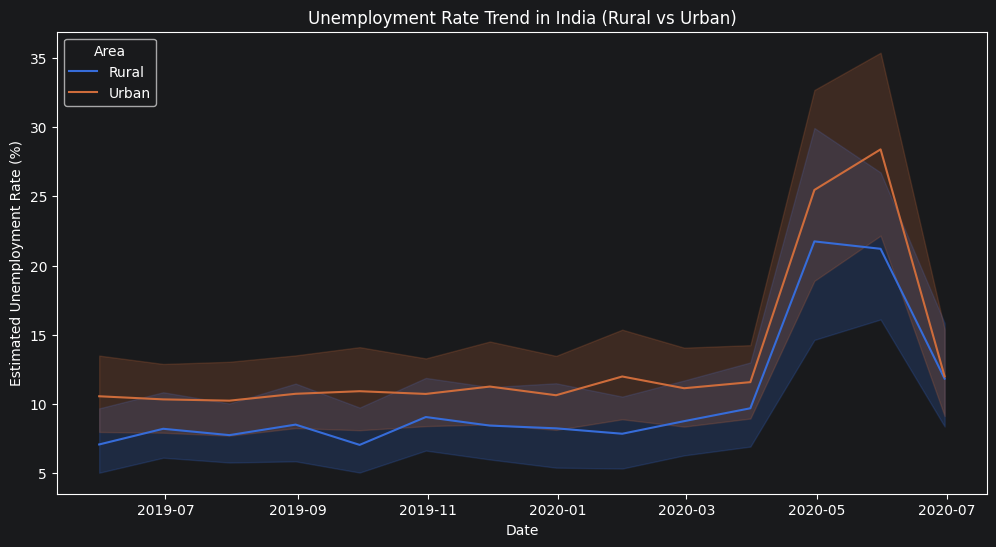

In [14]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Date', y='Estimated Unemployment Rate (%)', hue='Area')plt.title('Unemployment Rate Trend in India (Rural vs Urban)')
plt.show()

# B. Regional Comparison

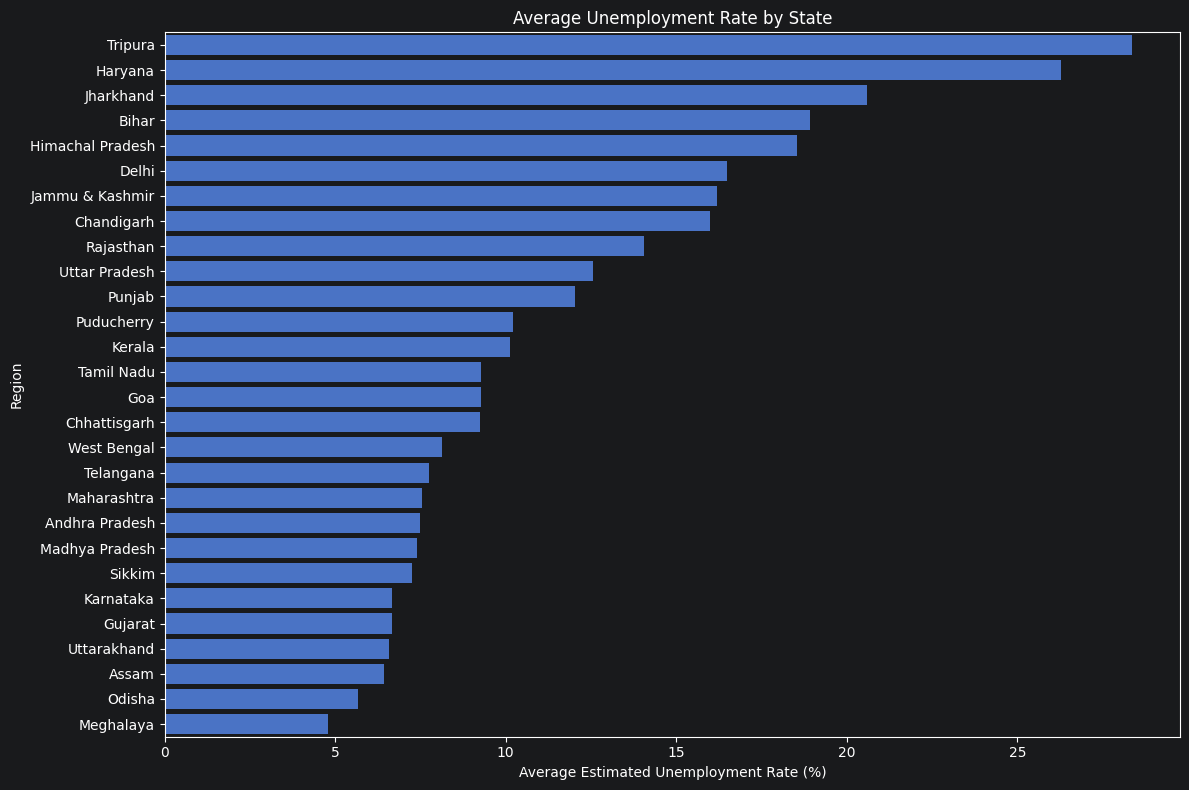

In [15]:
plt.figure(figsize=(12, 8))

region_unemployment = (
    df.groupby('Region', as_index=False)['Estimated Unemployment Rate (%)']
    .mean()
    .sort_values(by='Estimated Unemployment Rate (%)', ascending=False)
)

sns.barplot(
    x='Estimated Unemployment Rate (%)',
    y='Region',
    data=region_unemployment,
    errorbar=None
)

plt.title('Average Unemployment Rate by State')
plt.xlabel('Average Estimated Unemployment Rate (%)')
plt.ylabel('Region')
plt.tight_layout()
plt.show()